In [1]:
%load_ext autoreload
%autoreload 2
%load_ext line_profiler
%matplotlib widget
    
import moabb
from moabb.datasets import *
from moabb.paradigms import P300
from hoda.hoda import HODA
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mne.viz import plot_topomap
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
from sklearn.manifold import TSNE
from mne.decoding import Scaler
from mne import combine_evoked

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


2023-10-04 13:18:18.209461: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Tensorflow not install, you could not use those pipelines
To use the get_shape_from_baseconcar, InputShapeSetterEEG, BraindecodeDatasetLoaderyou need to install `braindecode`.`pip install braindecode` or Please refer to `https://braindecode.org`.


In [2]:
fmax=16
sfreq=64
paradigm = P300(resample=sfreq, tmin=0, tmax=0.8, fmin=0.5, fmax=fmax)
#dataset = EPFLP300()
#subject, session, run = 1, "session_1", "run_1"
dataset = BNCI2014008()
subject, session, run = 2, "session_0", "run_0"


BNCI2014008 has been renamed to BNCI2014_008. BNCI2014008 will be removed in version 0.7.
The dataset class name 'BNCI2014008' must be an abbreviation of its code 'BNCI2014-008'. See moabb.datasets.base.is_abbrev for more information.


In [3]:
from moabb.paradigms import P300
from moabb.datasets import BNCI2014_008, BNCI2014_009
plt.style.use('default')

fmax=16
sfreq=32 
paradigm = P300(resample=sfreq, tmin=0, tmax=0.8, fmin=0.5, fmax=fmax)
dataset = BNCI2014_009()
epochs, labels, meta = paradigm.get_data(dataset=dataset, 
                                         subjects=[1],
                                         return_epochs=True)

Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
1728 matching events found
No baseline correction applied


/data/.virtualenvs/hoda/lib/python3.11/site-packages/moabb/paradigms/base.py:346: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  X = mne.concatenate_epochs(X)


In [4]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl

tl.set_backend('numpy')

X = epochs.get_data()
y = labels

X.shape

(1728, 16, 26)

In [8]:
from hoda.hoda import BTTDA
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mne.decoding import Scaler

n_blocks=4
bttda = BTTDA(
    n_blocks=n_blocks,
    hoda_params=dict(
            rank=[1,1],
            max_iter=32,
            tol=1e-8,
            init ='svd',
            shrinkage=('lw', 'lw'),
            toeplitz=None,
            obj='rt',
            solver='lanczos',
            taper=False,
            keep_train_info=False,
            verbose=True,
    ),
    keep_train_info=True,
    verbose=True)                   

bttda.fit(X,y)

Fitting block 1/4...
Initializing factors...
Fitting discriminative tucker model...


[autoreload of hoda.hoda failed: Traceback (most recent call last):
  File "/data/.virtualenvs/hoda/lib/python3.11/site-packages/IPython/extensions/autoreload.py", line 276, in check
    superreload(m, reload, self.old_objects)
  File "/data/.virtualenvs/hoda/lib/python3.11/site-packages/IPython/extensions/autoreload.py", line 475, in superreload
    module = reload(module)
             ^^^^^^^^^^^^^^
  File "/usr/lib64/python3.11/importlib/__init__.py", line 169, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 621, in _exec
  File "<frozen importlib._bootstrap_external>", line 936, in exec_module
  File "<frozen importlib._bootstrap_external>", line 1074, in get_code
  File "<frozen importlib._bootstrap_external>", line 1004, in source_to_code
  File "<frozen importlib._bootstrap>", line 241, in _call_with_frames_removed
  File "/data/Workspace/PhD/hoda-bci/hoda/hoda.py", line 361
    -0.5
    ^^^^^^^^^^^^^
SyntaxError: invalid syntax. Perhaps

  0%|          | 0/32 [00:00<?, ?it/s]

[1.94076805e-07]
[1.94076805e-07]
[4.41773528e-07]
[4.41773528e-07]
[7.59132547e-07]
[7.59132547e-07]
[6.80511393e-07]
[6.80511393e-07]
[8.71037163e-07]
[8.71037163e-07]
[8.3257121e-07]
[8.3257121e-07]
[8.95198085e-07]
[8.95198085e-07]
[8.9103848e-07]
[8.9103848e-07]
[9.00757907e-07]
[9.00757907e-07]
[9.04884658e-07]
[9.04884658e-07]
[9.02657209e-07]
[9.02657209e-07]
[9.062942e-07]
[9.062942e-07]
[9.03442224e-07]
[9.03442224e-07]
[9.05555941e-07]
[9.05555941e-07]
[9.03773864e-07]
[9.03773864e-07]
[9.04860836e-07]
[9.04860836e-07]
[9.03914404e-07]
[9.03914404e-07]
[9.04448538e-07]
[9.04448538e-07]
[9.03974926e-07]
[9.03974926e-07]
[9.04232844e-07]
[9.04232844e-07]
[9.04001631e-07]
[9.04001631e-07]
[9.04125371e-07]
[9.04125371e-07]
[9.04013708e-07]
[9.04013708e-07]
Fitted tucker model of rank [1, 1] ...

Fitting block 2/4...
Initializing factors...
Fitting discriminative tucker model...


  0%|          | 0/32 [00:00<?, ?it/s]

...

  0%|          | 0/32 [00:00<?, ?it/s]

[8.07912079e-08]
[8.07912079e-08]
[3.33757947e-07]
[3.33757947e-07]
[2.08648988e-07]
[2.08648988e-07]
[3.57450713e-07]
[3.57450713e-07]
[2.63107404e-07]
[2.63107404e-07]
[3.39245662e-07]
[3.39245662e-07]
[2.73661835e-07]
[2.73661835e-07]
[3.22870638e-07]
[3.22870638e-07]
[2.77586348e-07]
[2.77586348e-07]
[3.13506369e-07]
[3.13506369e-07]
[2.81697035e-07]
[2.81697035e-07]
[3.08006088e-07]
[3.08006088e-07]
[2.85657833e-07]
[2.85657833e-07]
[3.04636444e-07]
[3.04636444e-07]
[2.88999324e-07]
[2.88999324e-07]
[3.0252061e-07]
[3.0252061e-07]
[2.91624806e-07]
[2.91624806e-07]
[3.01169079e-07]
[3.01169079e-07]
[2.93599392e-07]
[2.93599392e-07]
[3.00293592e-07]
[3.00293592e-07]
[2.95043756e-07]
[2.95043756e-07]
[2.99719627e-07]
[2.99719627e-07]
[2.96081735e-07]
[2.96081735e-07]
[2.9933945e-07]
[2.9933945e-07]
[2.96819221e-07]
[2.96819221e-07]
[2.9908543e-07]
[2.9908543e-07]
[2.97339342e-07]
[2.97339342e-07]
[2.98914461e-07]
[2.98914461e-07]
[2.97704391e-07]
[2.97704391e-07]
[2.9879869e-07]
[2.9

  0%|          | 0/32 [00:00<?, ?it/s]

[3.92874894e-09]
[3.92874894e-09]
[4.15568956e-08]
[4.15568956e-08]
[4.12661613e-08]
[4.12661613e-08]
[5.57621723e-08]
[5.57621723e-08]
[6.13659645e-08]
[6.13659645e-08]
[6.31971658e-08]
[6.31971658e-08]
[7.22232459e-08]
[7.22232459e-08]
[7.0375601e-08]
[7.0375601e-08]
[8.249399e-08]
[8.249399e-08]
[8.1510125e-08]
[8.1510125e-08]
[9.5875071e-08]
[9.5875071e-08]
[9.78319604e-08]
[9.78319604e-08]
[1.12199967e-07]
[1.12199967e-07]
[1.17728079e-07]
[1.17728079e-07]
[1.28965819e-07]
[1.28965819e-07]
[1.367147e-07]
[1.367147e-07]
[1.44023045e-07]
[1.44023045e-07]
[1.50784354e-07]
[1.50784354e-07]
[1.56034791e-07]
[1.56034791e-07]
[1.60177753e-07]
[1.60177753e-07]
[1.64554412e-07]
[1.64554412e-07]
[1.66611675e-07]
[1.66611675e-07]
[1.70273024e-07]
[1.70273024e-07]
[1.71092229e-07]
[1.71092229e-07]
[1.74089216e-07]
[1.74089216e-07]
[1.74194321e-07]
[1.74194321e-07]
[1.76659128e-07]
[1.76659128e-07]
[1.76339801e-07]
[1.76339801e-07]
[1.78411514e-07]
[1.78411514e-07]
[1.77841241e-07]
[1.77841241

BTTDA(hoda_params={'init': 'svd', 'keep_train_info': False, 'max_iter': 32,
                   'obj': 'rt', 'rank': [1, 1], 'shrinkage': ('lw', 'lw'),
                   'solver': 'lanczos', 'taper': False, 'toeplitz': None,
                   'tol': 1e-08, 'verbose': True},
      keep_train_info=True, n_blocks=4, verbose=True)

KeyError: 'aic'

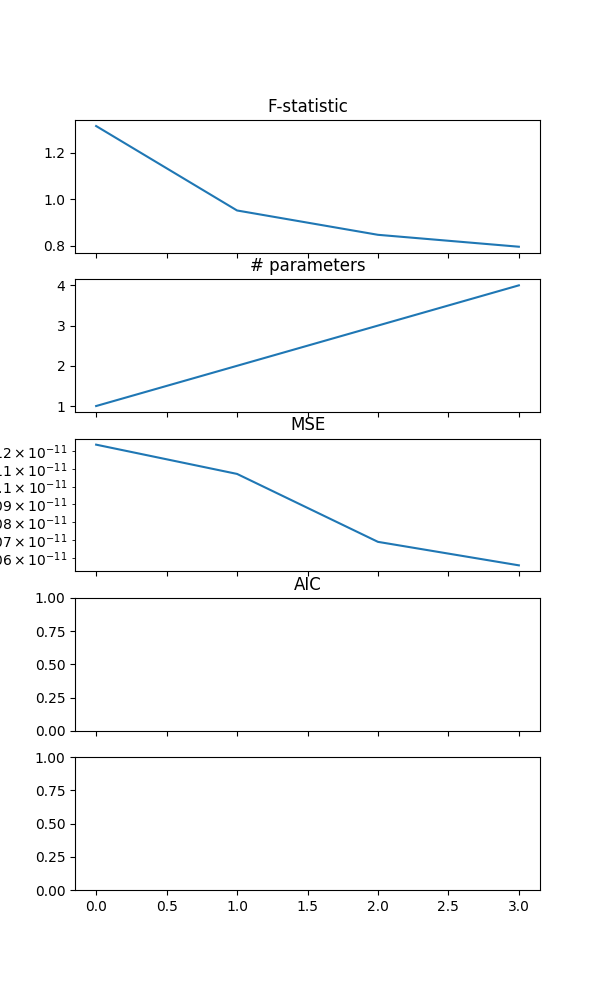

In [6]:
fig, axs = plt.subplots(3,1, sharex=True, figsize=(6,10))

axs[0].set_title('F-statistic')
axs[0].plot(bttda.train_info_["f_stat"])

axs[1].set_title('# parameters')
axs[1].plot(bttda.train_info_["n_params"])

axs[2].set_title('MSE')
axs[2].semilogy(bttda.train_info_["mse"])



In [ ]:
import cupy

"""
fig, axs = plt.subplots(n_blocks, 2, figsize=(8,16))
for b in range(len(bttda.blocks_)):
    for k in range(2):
        scatter_w = cupy.asnumpy(bttda.blocks_[b].scatter_w_[k])
        vmax = np.max(np.abs(scatter_w))
        sns.heatmap(scatter_w, cmap='BrBG',
                    vmin=-vmax, vmax=vmax, ax=axs[b,k])    
        axs[b,k].set_aspect('equal')
"""

In [ ]:
joint_args=dict(ts_args=dict(ylim=dict(eeg=[-5,5])))


target = epochs['Target'].average()
non_target = epochs['NonTarget'].average()
contrast = combine_evoked([target,non_target], weights=[1,-1])
_ = contrast.plot_joint(**joint_args)

In [ ]:
from mne import combine_evoked

for b in range(len(bttda.blocks_)):
    epochs_rec = epochs.copy()
    epochs_rec._data = bttda.blocks_[b].inv_transform(bttda.blocks_[b].transform(epochs_rec.get_data()))
    
    target = epochs_rec['Target'].average()
    non_target = epochs_rec['NonTarget'].average()
    contrast = combine_evoked([target,non_target], weights=[1,-1])
    _ = contrast.plot_joint(**joint_args)


In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
import pandas as pd

Xt = bttda.transform(X)
Xt_flat = cupy.asnumpy(Xt.reshape((Xt.shape[0],-1)))
lda = LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr') 
lda.fit(Xt_flat, y)
score_pred = lda.decision_function(Xt_flat)
df = pd.DataFrame(dict(score=score_pred,y=y))
sns.displot(df, x='score', hue='y')
plt.axvline(0, color='red')
print(roc_auc_score(y,score_pred))